# Training using train.csv, 4 labels, batch size 32
# 14/04/2025 16:39

In [3]:
# Initialize Paths
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parent
metrics_path = project_root / 'src' / 'models' / 'llm' / 'multi-task-disaster-classifier' /'metrics'

In [8]:
# Load metrics for each epoch
import json

eval_logs = []
for file in metrics_path.iterdir():
    if file:
        with open(file, 'r') as f:
            data = json.load(f)
            eval_logs.append(data)

eval_logs.sort(key= lambda x: x['epoch'])

# View sorted data after loading
import pandas as pd
df = pd.DataFrame(eval_logs)
df.head(10)

""


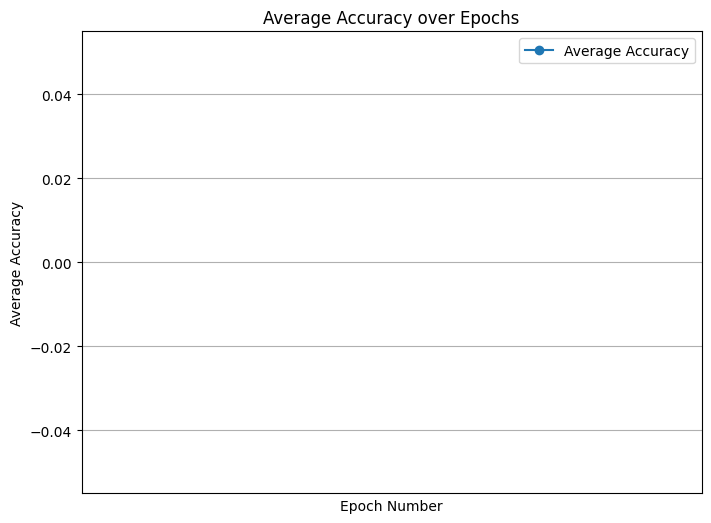

In [5]:
# Plot average accuracy against epochs
import matplotlib.pyplot as plt

# Extract epoch numbers and sentiment accuracies
epochs = [log['epoch'] for log in eval_logs]
average_accuracies = [log['eval_avg_accuracy'] for log in eval_logs]

# Plot sentiment accuracy over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, average_accuracies, marker='o', linestyle='-', label='Average Accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Average Accuracy')
plt.title('Average Accuracy over Epochs')
plt.xticks(epochs)  # Show all epoch points on x-axis
plt.legend()
plt.grid(True)
plt.show()

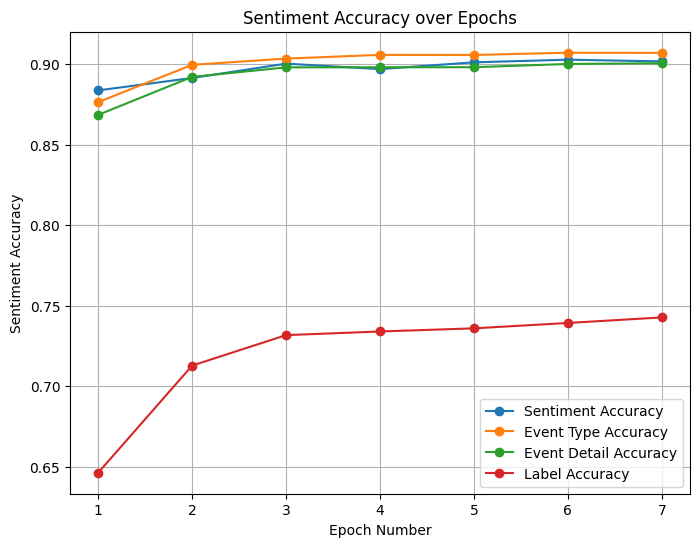

In [40]:
# Plot sentiment accuracy against epochs
import matplotlib.pyplot as plt

# Extract epoch numbers and sentiment accuracies
epochs = [log['epoch'] for log in eval_logs]
sentiment_accuracies = [log['eval_sentiment_accuracy'] for log in eval_logs]
event_type_accuracies = [log['eval_event_type_accuracy'] for log in eval_logs]
event_detail_accuracies = [log['eval_event_detail_accuracy'] for log in eval_logs]
label_accuracies = [log['eval_label_accuracy'] for log in eval_logs]

# Plot sentiment accuracy over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, sentiment_accuracies, marker='o', linestyle='-', label='Sentiment Accuracy')
plt.plot(epochs, event_type_accuracies, marker='o', linestyle='-', label='Event Type Accuracy')
plt.plot(epochs, event_detail_accuracies, marker='o', linestyle='-', label='Event Detail Accuracy')
plt.plot(epochs, label_accuracies, marker='o', linestyle='-', label='Label Accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Sentiment Accuracy')
plt.title('Sentiment Accuracy over Epochs')
plt.xticks(epochs)  # Show all epoch points on x-axis
plt.legend()
plt.grid(True)
plt.show()

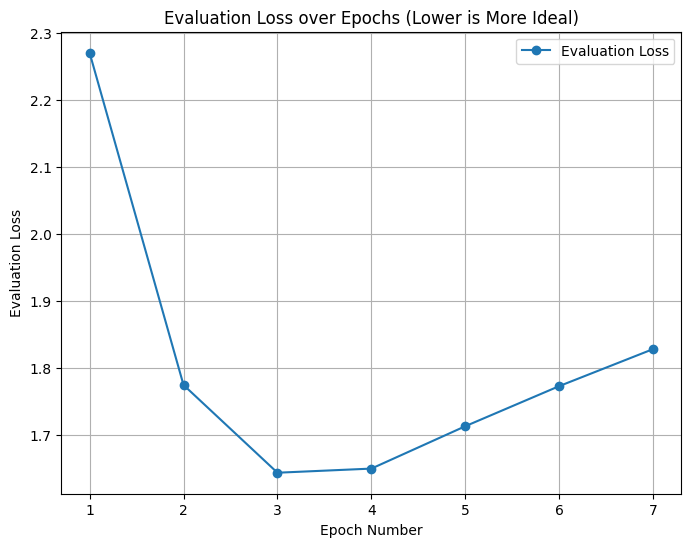

In [41]:
# Plot entropy loss against epochs
import matplotlib.pyplot as plt

# Extract epoch numbers and sentiment accuracies
epochs = [log['epoch'] for log in eval_logs]
entropy_loss = [log['eval_loss'] for log in eval_logs]

# Plot sentiment accuracy over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, entropy_loss, marker='o', linestyle='-', label='Evaluation Loss')
plt.xlabel('Epoch Number')
plt.ylabel('Evaluation Loss')
plt.title('Evaluation Loss over Epochs (Lower is More Ideal)')
plt.xticks(epochs)  # Show all epoch points on x-axis
plt.legend()
plt.grid(True)
plt.show()

Test Results:
sentiment_accuracy: 0.9019
event_type_accuracy: 0.3304
event_detail_accuracy: 0.4950
label_accuracy: 0.0374
avg_accuracy: 0.4412

Sentiment Classification Report:
              precision    recall  f1-score   support

    negative       0.94      0.87      0.90     10269
    positive       0.87      0.94      0.90      9209

    accuracy                           0.90     19478
   macro avg       0.90      0.90      0.90     19478
weighted avg       0.90      0.90      0.90     19478


Event Type Classification Report:
              precision    recall  f1-score   support

       storm       0.93      0.91      0.92      6325
       flood       0.05      0.16      0.07      2253
     unknown       0.02      0.01      0.01      7601
  earthquake       0.00      0.00      0.00      1949
        fire       0.00      0.00      0.00       925
      meteor       0.00      0.00      0.00        74
   landslide       0.80      0.64      0.71       264
        haze       0.96      1.00      0.98        55
     volcano       1.00      0.88      0.93        32

    accuracy                           0.33     19478
   macro avg       0.42      0.40      0.40     19478
weighted avg       0.33      0.33      0.32     19478


Event Detail Classification Report:
              precision    recall  f1-score   support

     tornado       0.66      0.71      0.68       867
       flood       0.01      0.02      0.02      2250
     unknown       0.89      0.94      0.92      7601
   hurricane       0.02      0.01      0.01      4442
     typhoon       0.99      0.98      0.98       745
  earthquake       0.00      0.00      0.00      1949
   wild_fire       0.95      0.96      0.96       865
      meteor       0.99      1.00      0.99        74
     cyclone       0.00      0.00      0.00       271
   landslide       0.80      0.64      0.71       264
   bush_fire       0.00      0.00      0.00        60
        haze       0.00      0.00      0.00        55
     tsunami       0.00      0.00      0.00         3
     volcano       0.00      0.00      0.00        32

    accuracy                           0.49     19478
   macro avg       0.38      0.38      0.38     19478
weighted avg       0.48      0.49      0.49     19478


Label Classification Report:
C:\Users\UserAdmin\Documents\projects\hadr-sentiment-analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\UserAdmin\Documents\projects\hadr-sentiment-analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\UserAdmin\Documents\projects\hadr-sentiment-analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
                                                                       precision    recall  f1-score   support

                                                            off-topic       0.06      0.06      0.06      1238
                                                         not_relevant       0.00      0.00      0.00       869
                                                          target_zero       0.05      0.01      0.02      4906
                                     displaced_people_and_evacuations       0.00      0.00      0.00       425
                                           Other Relevant Information       0.00      0.00      0.00       129
                                                             relevant       0.00      0.01      0.00       606
                        informative_infrastructure_and_utility_damage       0.00      0.00      0.00        83
                                               injured_or_dead_people       0.00      0.00      0.00       760
                                                          informative       0.00      0.00      0.00      1807
        Related - but not informative_Affected individuals_Eyewitness       0.00      0.00      0.00         6
                               informative_other_relevant_information       0.69      0.68      0.68       538
                                                             on-topic       0.00      0.00      0.00       976
                   Related and informative_Affected individuals_Media       0.00      0.00      0.00        70
                                                   caution_and_advice       0.00      0.00      0.00       583
                                    infrastructure_and_utility_damage       0.00      0.00      0.00       777
                                           other_relevant_information       0.00      0.00      0.00      1174
                                                     not_humanitarian       0.00      0.01      0.00       573
                                                      Not Informative       0.00      0.00      0.00       411
           Related and informative_Other Useful Information_Outsiders       0.00      0.00      0.00        44
                                     not_informative_not_humanitarian       0.77      0.57      0.66       378
                                              missing_or_found_people       0.00      0.00      0.00        34
                                                      not_informative       0.00      0.00      0.00      1368
                                         Infrastructure and utilities       0.00      0.00      0.00         6
                                           Other relevant information       0.00      0.00      0.00        25
                                             other_useful_information       0.00      0.00      0.00       268
                                            not_related_or_irrelevant       0.00      0.00      0.00       123
                                                   Physical landslide       0.00      0.00      0.00        40
                                                Infrastructure Damage       0.00      0.00      0.00        16
                                  infrastructure_and_utilities_damage       0.00      0.00      0.00        67
                                             requests_or_urgent_needs       0.00      0.00      0.00       211
                                               Not physical landslide       0.00      0.00      0.00       224
                                            Humanitarian Aid Provided       0.00      0.00      0.00        24
                                  Not related_Not labeled_Not labeled       0.00      0.00      0.00       109
                                   informative_injured_or_dead_people       0.00      0.00      0.00        34
           Related and informative_Infrastructure and utilities_Media       0.00      0.00      0.00        23
                     Related and informative_Caution and advice_Media       0.00      0.00      0.00        52
                                                            Off-topic       0.00      0.00      0.00        27
    Related - but not informative_Other Useful Information_Eyewitness       0.00      0.00      0.00        11
       Related and informative_Infrastructure and utilities_Outsiders       0.00      0.00      0.00         4
                                     informative_affected_individuals       0.00      0.00      0.00        30
                                            Not related or irrelevant       0.00      0.00      0.00        14
                     Related and informative_Not applicable_Outsiders       0.00      0.00      0.00         2
                                                     Response Efforts       0.00      0.00      0.00         1
               Related and informative_Other Useful Information_Media       0.00      0.00      0.00        97
                               Not applicable_Not labeled_Not labeled       0.00      0.00      0.00        11
          Related and informative_Other Useful Information_Eyewitness       0.00      0.00      0.00        15
    Related - but not informative_Other Useful Information_Government       0.00      0.00      0.00         1
                 Related and informative_Caution and advice_Outsiders       0.00      0.00      0.00        11
                                                   Caution and advice       0.00      0.00      0.00        13
     Related - but not informative_Other Useful Information_Outsiders       0.00      0.00      0.00        23
                                                 Shelter and supplies       0.00      0.00      0.00         1
                                               Injured or dead people       0.00      0.00      0.00         2
                                                Not related to crisis       0.00      0.00      0.00        16
               Related - but not informative_Not applicable_Outsiders       0.00      0.00      0.00        14
               Related and informative_Affected individuals_Outsiders       0.00      0.00      0.00        18
                Related and informative_Caution and advice_Eyewitness       0.00      0.00      0.00         5
      Related - but not informative_Other Useful Information_Business       0.00      0.00      0.00         2
             Related - but not informative_Affected individuals_Media       0.00      0.00      0.00         2
         Related - but not informative_Other Useful Information_Media       0.00      0.00      0.00        12
      Related and informative_Infrastructure and utilities_Government       0.00      0.00      0.00        11
                                             Other useful information       0.00      0.00      0.00        12
          Related and informative_Other Useful Information_Government       0.00      0.00      0.00         5
                                      missing_trapped_or_found_people       0.00      0.00      0.00        13
              Related and informative_Affected individuals_Eyewitness       0.00      0.00      0.00        13
Related - but not informative_Other Useful Information_Not applicable       0.00      0.00      0.00         2
      Related and informative_Other Useful Information_Not applicable       0.00      0.00      0.00         1
                Related and informative_Caution and advice_Government       0.00      0.00      0.00        14
                                                          Informative       0.00      0.00      0.00        12
      Related and informative_Infrastructure and utilities_Eyewitness       0.00      0.00      0.00        10
                      Related and informative_Caution and advice_NGOs       0.00      0.00      0.00         2
                                           informative_vehicle_damage       0.00      0.00      0.00         5
              Related - but not informative_Not applicable_Eyewitness       0.00      0.00      0.00        16
                                                     Injured and dead       0.00      0.00      0.00         2
                                                     Personal updates       0.00      0.00      0.00         2
          Related - but not informative_Not applicable_Not applicable       0.00      0.00      0.00         3
          Related - but not informative_Caution and advice_Government       0.00      0.00      0.00         2
        Related - but not informative_Affected individuals_Government       0.00      0.00      0.00         1
Related - but not informative_Infrastructure and utilities_Eyewitness       0.00      0.00      0.00         3
                         Related and informative_Not applicable_Media       0.00      0.00      0.00         3
              Related and informative_Affected individuals_Government       0.00      0.00      0.00         8
                      Related and informative_Not applicable_Business       0.00      0.00      0.00         1
                                                     Displaced people       0.00      0.00      0.00         1
                                                      Not informative       0.00      0.00      0.00         1
        Related and informative_Infrastructure and utilities_Business       0.00      0.00      0.00         2
                                              Requests for Help/Needs       0.00      0.00      0.00         5
                                  informative_missing_or_found_people       0.00      0.00      0.00         3
                    Related and informative_Affected individuals_NGOs       0.00      0.00      0.00         2
                Related and informative_Other Useful Information_NGOs       0.00      0.00      0.00         4
                  Related and informative_Caution and advice_Business       0.00      0.00      0.00         1
                   Related - but not informative_Not applicable_Media       0.00      0.00      0.00         2
           Related - but not informative_Caution and advice_Outsiders       0.00      0.00      0.00         1
  Related and informative_Infrastructure and utilities_Not applicable       0.00      0.00      0.00         1
                Related - but not informative_Not applicable_Business       0.00      0.00      0.00         1
     Related - but not informative_Infrastructure and utilities_Media       0.00      0.00      0.00         1
                                                         Not Relevant       0.00      0.00      0.00         1
      Related - but not informative_Caution and advice_Not applicable       0.00      0.00      0.00         1
         Related - but not informative_Affected individuals_Outsiders       0.00      0.00      0.00         1

                                                             accuracy                           0.04     19478
                                                            macro avg       0.02      0.01      0.01     19478
                                                         weighted avg       0.05      0.04      0.04     19478

Generating confusion matrices...

         Related - but not informative_Affected individuals_Outsiders       0.00      0.00      0.00         1

                                                             accuracy                           0.04     19478
                                                            macro avg       0.02      0.01      0.01     19478
                                                         weighted avg       0.05      0.04      0.04     19478

Generating confusion matrices...

                                                            macro avg       0.02      0.01      0.01     19478
                                                         weighted avg       0.05      0.04      0.04     19478

Generating confusion matrices...

Generating confusion matrices...


Testing complete. Results saved to results

Testing on individual examples:

Example 1: 'Earthquake in California has caused significant damage to infrastructure.'
  - sentiment: positive
  - event_type: unknown
  - event_detail: hurricane
  - label: Not related_Not labeled_Not labeled

Example 2: 'The flood has destroyed homes and displaced thousands of people.'
  - sentiment: positive
  - event_type: meteor
  - event_detail: cyclone
  - label: Not physical landslide

Example 3: 'New storm warning issued for the coastal areas. Residents advised to evacuate.'
  - sentiment: positive
  - event_type: storm
  - event_detail: flood
  - label: Not physical landslide

Example 4: 'Forest fire continues to spread due to strong winds.'
  - sentiment: positive
  - event_type: earthquake
  - event_detail: wild_fire
  - label: informative